# Figure 5 

### Setup: Parameters, Time Windows, Mappings, and Paths

In [1]:
import numpy as np

BUFFER_BEFORE_SEC = 0.5  # Spont
BUFFER_AFTER_SEC = 2.5 + 1.4  # Sound-Persist
SoundTypes = [101, 400, 1300]
t_trial = np.arange(-BUFFER_BEFORE_SEC, BUFFER_AFTER_SEC, 0.05)
t_trial_centers = (t_trial[:-1] + t_trial[1:]) / 2

time_windows_dict = {
    'Spontaneous': (-np.inf, -0.01), 
    'Sound': (0, 2.5), 
    'Persistence': (2.5, BUFFER_AFTER_SEC), 
}

# Colorblind-friendly colors
colors = {
    'wake': 'deeppink',
    'sleep': '#2E8B57',
    'high': 'deeppink',
    'low': '#4682B4'
}

window_colors = {
    'Spontaneous': 'gray',
    'Sound': '#4B0082',
    'Persistence': '#FF4500'
}
name_mapping = {'Spontaneous': 'Pre',
                'Sound': 'Peri', 'Persistence': 'Post', 'low': 'Early', 'high': 'Late', 'sleep': 'SLEEP', 'wake': 'WAKE'}

MAIN_PATH = r'input_path'  ## Path to where the raw data is saved (raw data is not available due to size)
DATA_PATH = MAIN_PATH + rf"\Submission"  ## Path to where the processed data is saved (after we ran PROCESS_RAW=True)

### Subject-Specific Configuration: Dates, Channel Ranges, and Max Recording Time

In [2]:
subjects_data = {
    'C9': {
        'folders_dates_to_collect': ['20240312', '20240317', '20240319'],
        'MAX_HOUR_IN_SECONDS': 60 * 60 * 2,
        'high_ch': [0, 100],
        'low_ch': [100, 200]
    },
    'C11': {
        'folders_dates_to_collect': ['20240911', '20240917'],
        'MAX_HOUR_IN_SECONDS': 60 * 60 * 4,
        'high_ch': [50, 150],
        'low_ch': [150, 250]
    },
    'C12': {
        'folders_dates_to_collect': ['20241007', '20241008'],
        'MAX_HOUR_IN_SECONDS': 60 * 60 * 4,
        'high_ch': [90, 190],
        'low_ch': [190, 290]
    },
    'C14': {
        'folders_dates_to_collect': ['20241112', '20241113'],
        'MAX_HOUR_IN_SECONDS': 60 * 60 * 4,
        'high_ch': [100, 200],
        'low_ch': [200, 300]
    },
    'C16': {
        'folders_dates_to_collect': ['20250211', '20250212'],
        'MAX_HOUR_IN_SECONDS': 60 * 60 * 4,
        'high_ch': [150, 250],
        'low_ch': [250, 350]
    }
}

## Load df from Figure 4

The DataFrame contains trial-resolved spiking activity for every subject, session, sound type, brain region (low/high), and state (wake/NREM/REM).

In [3]:
import pickle

save_path_df = DATA_PATH + r"\df_GLMs.pkl"
with open(save_path_df, 'rb') as f:
    df = pickle.load(f)

## Group df by Subject/Session/State/SoundType/Region

In [4]:
import numpy as np
import pandas as pd

def aggregate_spikes_by_condition(df,
                                  group_cols=['Subject','Date','State','SoundType','Region'],
                                  spikes_col='Spikes_matrix'):
    """
    Group df by group_cols and stack Spikes_matrix arrays for each group.

    Input:
      df            - DataFrame where each row is one trial and df[spikes_col] is (n_neurons, n_time_bins)
      group_cols    - columns to group by (must exist in df)
      spikes_col    - column name with the per-trial 2D array

    Output:
      df_agg - DataFrame with one row per group and a 'Spikes' column containing
               a numpy array shaped (n_trials, n_neurons, n_time_bins)
    """
    agg_rows = []
    # drop rows with missing spikes to avoid errors
    df_clean = df.dropna(subset=[spikes_col]).copy()

    for key, grp in df_clean.groupby(group_cols, sort=False):
        # key is either a single value or a tuple (depending on number of group_cols)
        mats = list(grp[spikes_col].values)

        # Check shapes are identical
        shapes = [m.shape for m in mats]
        unique_shapes = set(shapes)
        if len(unique_shapes) != 1:
            raise ValueError(f"Inconsistent spike-matrix shapes in group {key}: {unique_shapes}")

        # stack -> (n_trials, n_neurons, n_timebins)
        stacked = np.stack(mats, axis=0).astype(float)

        # unpack key into dict
        if isinstance(key, tuple):
            meta = dict(zip(group_cols, key))
        else:
            meta = {group_cols[0]: key}

        meta.update({
            'n_trials': stacked.shape[0],
            'n_neurons': stacked.shape[1],
            'n_time_bins': stacked.shape[2],
            'Spikes': stacked
        })
        agg_rows.append(meta)

    df_agg = pd.DataFrame(agg_rows)
    return df_agg

df_filt = df.copy()
df_agg = aggregate_spikes_by_condition(df_filt)
df_agg = df_agg[
    df_agg['State'].isin(['sleep', 'wake']) &
    df_agg['Region'].isin(['low', 'high']) &
    df_agg['SoundType'].isin(SoundTypes) 
].copy()

In [5]:
ind_check = 56

print(df_agg.loc[ind_check, ['Subject','Date','State','SoundType','Region','n_trials','n_neurons','n_time_bins']])
print("Spikes array shape:", df_agg.loc[ind_check, 'Spikes'].shape)

Subject              C9
Date           20240319
State              wake
SoundType          1300
Region              low
n_trials             63
n_neurons            86
n_time_bins          87
Name: 56, dtype: object
Spikes array shape: (63, 86, 87)


## Compute Features across Groups

In [6]:
import numpy as np
import pandas as pd

def compute_trialwise_stats(df_agg,
                           group_cols=['Subject','Date','State','SoundType','Region']):
    """
    Compute trial-wise statistics from aggregated spike data.

    Input:
        df_agg['Spikes']: (n_trials, n_neurons, n_time_bins)

    Output per row:
        mean_FR        : (n_neurons, n_time_bins)
        std_FR         : (n_neurons, n_time_bins)
        FANO           : (n_neurons, n_time_bins)
        Fano_pop       : (n_time_bins,)
        trial_var      : (n_neurons, n_time_bins)
        reliability    : (n_neurons, n_time_bins)
        pairwise_corr  : (n_time_bins,)
    """

    rows = []

    for _, row in df_agg.iterrows():
        spikes = row['Spikes']  # (T, N, B)
        T, N, B = spikes.shape
        
        counts = spikes * np.mean(np.diff(t_trial))
        # -------------------------
        # 1. Firing rate
        # -------------------------
        mean_FR = np.mean(spikes, axis=0)          # (N, B)
        std_FR  = np.std(spikes, axis=0)           # (N, B)
            
        # ---------------------------------
        # 2. Trial variability (counts)
        # ---------------------------------
        trial_var = np.var(counts, axis=0)

        # ---------------------------------
        # 3. Fano factor (per neuron)
        # ---------------------------------
        mean_counts = np.mean(counts, axis=0)

        with np.errstate(divide='ignore', invalid='ignore'):
            FANO = trial_var / mean_counts
            FANO[np.isnan(FANO)] = 0

        # ---------------------------------
        # 4. Population Fano
        # (pool neurons → variance across trials)
        # ---------------------------------
        pop_counts = counts.mean(axis=1)  # (T, B)
        pop_mean = np.mean(pop_counts, axis=0)
        pop_var  = np.var(pop_counts, axis=0)

        with np.errstate(divide='ignore', invalid='ignore'):
            Fano_pop = pop_var / pop_mean
            Fano_pop[np.isnan(Fano_pop)] = 0

        # -------------------------
        # 5. Pairwise neuron correlation
        # -------------------------
        pairwise_corr = np.zeros(B)

        for b in range(B):
            data = spikes[:, :, b]  # (T, N)

            if data.shape[0] < 2:
                pairwise_corr[b] = 0
                continue

            corr_mat = np.corrcoef(data, rowvar=False)  # neurons x neurons
            upper = corr_mat[np.triu_indices_from(corr_mat, k=1)]

            pairwise_corr[b] = np.nanmean(upper)

        # -------------------------
        # Store results
        # -------------------------
        meta = {col: row[col] for col in group_cols}
        meta.update({
            'mean_FR': mean_FR,
            'std_FR': std_FR,
            'FANO': FANO,
            'Fano_pop': Fano_pop,
            'trial_var': trial_var,
            'pairwise_corr': pairwise_corr
        })

        rows.append(meta)

    return pd.DataFrame(rows)

df_stats = compute_trialwise_stats(df_agg)

D:\BarakH_codes\SpikeInterface\venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
D:\BarakH_codes\SpikeInterface\venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [7]:
df_stats.head(10)

,Subject,Date,State,SoundType,Region,mean_FR,std_FR,FANO,Fano_pop,trial_var,pairwise_corr
0,C9,20240312,wake,101,low,"[[1.2903225806451617, 0.860215053763441, 1.505...","[[5.722208471247341, 4.057626293357686, 6.7116...","[[1.2688172043010766, 0.9569892473118287, 1.49...","[0.054710172676122514, 0.04154270230593235, 0....","[[0.0818591744710372, 0.04116082784136898, 0.1...","[0.031548239760694145, 0.01854149946417013, 0...."
1,C9,20240312,wake,101,high,"[[1.2903225806451617, 1.0752688172043015, 0.64...","[[5.722208471247345, 6.128088967215055, 4.5922...","[[1.2688172043010746, 1.7462365591397857, 1.63...","[0.02401780832617354, 0.049369826204611715, 0....","[[0.08185917447103706, 0.0938836859752573, 0.0...","[0.011310258669387594, 0.027618924638855576, 0..."
2,C9,20240312,sleep,101,low,"[[0.892857142857143, 1.9642857142857149, 1.607...","[[4.130369109364425, 11.326272059928186, 8.079...","[[0.9553571428571457, 3.2654220779220697, 2.03...","[0.060773581007753145, 0.05375279536568209, 0....","[[0.04264987244897972, 0.3207110969387747, 0.1...","[0.03216775615474772, 0.025445318183948688, 0...."
3,C9,20240312,sleep,101,high,"[[2.6785714285714293, 1.4285714285714288, 0.71...","[[9.818181281350908, 5.150787536377128, 4.5736...","[[1.7994047619047642, 0.9285714285714264, 1.46...","[0.05860470048257614, 0.03770695746547825, 0.0...","[[0.24099170918367377, 0.06632653061224474, 0....","[0.03131021800143399, 0.0193407912702995, 0.01..."
4,C9,20240312,wake,400,low,"[[1.1009174311926606, 0.9174311926605506, 0.0,...","[[5.305259557725116, 4.184130000363809, 0.0, 4...","[[1.278287461773695, 0.9541284403669724, 0.0, ...","[0.05232530851550287, 0.05092865653980644, 0.0...","[[0.07036444743708413, 0.04376735964986112, 0....","[0.02957237007658185, 0.02833018385695497, 0.0..."
5,C9,20240312,wake,400,high,"[[1.8348623853211012, 1.8348623853211015, 1.83...","[[8.795864083821566, 9.203622902006938, 9.5940...","[[2.108256880733939, 2.3082568807339454, 2.508...","[0.04268681546515475, 0.05456392007168418, 0.0...","[[0.19341806245265497, 0.21176668630586656, 0....","[0.02011153675914688, 0.024031888840297055, 0...."
6,C9,20240312,sleep,400,low,"[[1.5841584158415845, 1.1881188118811883, 0.59...","[[10.410645091560342, 8.359156799685337, 3.395...","[[3.4207920792079283, 2.9405940594059445, 0.97...","[0.06425981401558958, 0.05481270387761041, 0.0...","[[0.27095382805607354, 0.17468875600431352, 0....","[0.0326425413300836, 0.024567484716759798, 0.0..."
7,C9,20240312,sleep,400,high,"[[1.3861386138613865, 0.9900990099009902, 1.18...","[[5.8070805143030455, 5.171312814732913, 5.501...","[[1.2164073550212156, 1.3504950495049557, 1.27...","[0.04270166985667675, 0.046835754982216704, 0....","[[0.08430546024899514, 0.06685619056955226, 0....","[0.019225017516494775, 0.024653171399257937, 0..."
8,C9,20240312,wake,1300,low,"[[0.4081632653061225, 0.4081632653061225, 0.61...","[[2.827838053173679, 2.827838053173675, 3.4452...","[[0.9795918367346942, 0.9795918367346945, 0.96...","[0.052729963794987574, 0.05119762255338199, 0....","[[0.019991670137442737, 0.019991670137442744, ...","[0.029724737409357903, 0.024192478482876315, 0..."
9,C9,20240312,wake,1300,high,"[[0.816326530612245, 0.816326530612245, 0.4081...","[[3.9572896795235266, 3.9572896795235266, 2.82...","[[0.9591836734693887, 0.9591836734693887, 0.97...","[0.04008519549447255, 0.03588694430151922, 0.0...","[[0.03915035401915872, 0.03915035401915872, 0....","[0.02052815743134807, 0.016681252903070713, 0...."


In [8]:
import numpy as np
import pandas as pd

def collapse_neuron_level(df_stats,
                         group_cols=['Subject','Date','State','SoundType','Region']):
    """
    Collapse neuron-level metrics to time-bin level.

    Rules:
    - If metric is (N, B) → average across neurons → (B,)
    - If metric is already (B,) → keep as is
    - Ignores non-array columns

    Output:
        DataFrame with same grouping columns and all metrics as (B,)
    """

    rows = []

    for _, row in df_stats.iterrows():
        meta = {col: row[col] for col in group_cols}
        new_data = {}

        for col in df_stats.columns:
            if col in group_cols:
                continue

            val = row[col]

            # Skip non-arrays
            if not isinstance(val, np.ndarray):
                continue

            # Case 1: (N, B) → collapse neurons
            if val.ndim == 2:
                new_data[col] = np.nanmean(val, axis=0)

            # Case 2: already (B,) → keep
            elif val.ndim == 1:
                new_data[col] = val

            # Case 3: unexpected (e.g., scalar or higher dim)
            else:
                # optional: skip or store as-is
                continue

        meta.update(new_data)
        rows.append(meta)

    return pd.DataFrame(rows)

def hierarchical_average(df, group_cols=['Subject','Date','State','SoundType','Region']):
    """
    Hierarchical averaging:
    1. Average across dates per subject
    2. Average across soundtypes
    3. Average across subjects → mean + SEM
    """

    # detect metric columns automatically
    metric_cols = [c for c in df.columns if c not in group_cols]

    # 1. Average across dates
    df_date = (
        df.groupby(['Subject','State','SoundType','Region'])[metric_cols]
          .apply(lambda x: {m: np.mean(np.stack(x[m].values), axis=0) for m in metric_cols})
          .reset_index()
    )
    df_date = pd.concat([df_date.drop(0, axis=1), df_date[0].apply(pd.Series)], axis=1)

    # 2. Average across soundtypes
    df_sound = (
        df_date.groupby(['Subject','State','Region'])[metric_cols]
               .apply(lambda x: {m: np.mean(np.stack(x[m].values), axis=0) for m in metric_cols})
               .reset_index()
    )
    df_sound = pd.concat([df_sound.drop(0, axis=1), df_sound[0].apply(pd.Series)], axis=1)

    # 3. Across subjects
    rows = []
    for (state, region), subdf in df_sound.groupby(['State','Region']):
        row = {'State': state, 'Region': region}

        for m in metric_cols:
            arr = np.stack(subdf[m].values)  # (subjects, B)
            row[f'{m}_mean'] = arr.mean(axis=0)
            row[f'{m}_sem']  = arr.std(axis=0) / np.sqrt(arr.shape[0])

        rows.append(row)

    return pd.DataFrame(rows)

df_neuron_avg = collapse_neuron_level(df_stats)   # step 1: collapse neurons
df_final = hierarchical_average(df_neuron_avg)   # steps 2–3

In [9]:
print(df_final.columns)
df_final.head(5)

Index(['State', 'Region', 'mean_FR_mean', 'mean_FR_sem', 'std_FR_mean',
       'std_FR_sem', 'FANO_mean', 'FANO_sem', 'Fano_pop_mean', 'Fano_pop_sem',
       'trial_var_mean', 'trial_var_sem', 'pairwise_corr_mean',
       'pairwise_corr_sem'],
      dtype='object')


,State,Region,mean_FR_mean,mean_FR_sem,std_FR_mean,std_FR_sem,FANO_mean,FANO_sem,Fano_pop_mean,Fano_pop_sem,trial_var_mean,trial_var_sem,pairwise_corr_mean,pairwise_corr_sem
0,sleep,high,"[4.04367795376229, 4.080917997989053, 4.115757...","[0.7289514548666217, 0.7137135073146454, 0.739...","[8.995908595855667, 9.039916088965306, 9.05026...","[1.1713347572612, 1.1753846192331756, 1.152368...","[1.2760355861952248, 1.2630721771080864, 1.274...","[0.06904695494372512, 0.08032558761181342, 0.0...","[0.12773663805952748, 0.1279233041117915, 0.11...","[0.059325976864025194, 0.060266244483251886, 0...","[0.30815750826873456, 0.31053553484193847, 0.3...","[0.0704720531533375, 0.07152098522583968, 0.07...","[0.05185141531607902, 0.05220419240858635, 0.0...","[0.025586797768409823, 0.025987135724417063, 0..."
1,sleep,low,"[4.601115090523218, 4.6178798020637855, 4.6245...","[0.38929128495416654, 0.386670114436737, 0.395...","[9.438337223567489, 9.422888630334464, 9.46190...","[0.505264215018652, 0.46736705631798936, 0.496...","[1.1923592037787982, 1.1883863845856482, 1.191...","[0.04496189297158336, 0.04785285502077914, 0.0...","[0.1020148463183721, 0.09815215372395694, 0.09...","[0.021756017713784027, 0.0185539744334273, 0.0...","[0.3086016809423385, 0.30659304462135, 0.31014...","[0.03273326179935452, 0.030469036563518646, 0....","[0.05013016830692847, 0.04667710912416841, 0.0...","[0.012554291603503335, 0.009787338369851715, 0..."
2,wake,high,"[5.288104663318919, 5.322382231483428, 5.16500...","[0.5943948929150465, 0.6452168480809702, 0.629...","[10.850362016520558, 10.714717473087063, 10.50...","[0.3810982686625709, 0.37644599448292687, 0.30...","[1.5291597955331584, 1.4778781525411457, 1.473...","[0.2722631153876675, 0.22990955272325636, 0.23...","[0.25880736482642597, 0.25444576819261405, 0.2...","[0.13865614496390224, 0.13034420046453596, 0.1...","[0.504142881130362, 0.4715739969229983, 0.4725...","[0.0945313609864649, 0.05690320057509543, 0.06...","[0.054867493722396764, 0.0601278208988133, 0.0...","[0.0180602735316533, 0.01841406142364887, 0.01..."
3,wake,low,"[7.32902498458301, 7.366927789094577, 7.230455...","[1.1110043024236813, 1.1563723635874505, 1.074...","[11.56450985877583, 11.58996827303771, 11.5727...","[1.0630432203538676, 1.0822651571116881, 1.065...","[1.182952940886688, 1.1763821054328676, 1.2025...","[0.040539430619821286, 0.040378924791673786, 0...","[0.0814788245151327, 0.08149401152359295, 0.07...","[0.01890558132057838, 0.019906918347677056, 0....","[0.457381837644314, 0.4614947104885152, 0.4536...","[0.09176194754241399, 0.09653197842982279, 0.0...","[0.03926316711615991, 0.0391460500233864, 0.03...","[0.005772524320625859, 0.007879307048910801, 0..."


## Plotting: Metrics across time across all subjects

low Spontaneous: sleep=1.188±0.004, wake=1.184±0.009
low Sound: sleep=1.059±0.011, wake=1.106±0.007
low Persistence: sleep=1.145±0.022, wake=1.170±0.011
high Spontaneous: sleep=1.287±0.013, wake=1.480±0.035
high Sound: sleep=1.209±0.017, wake=1.399±0.048
high Persistence: sleep=1.254±0.029, wake=1.464±0.063


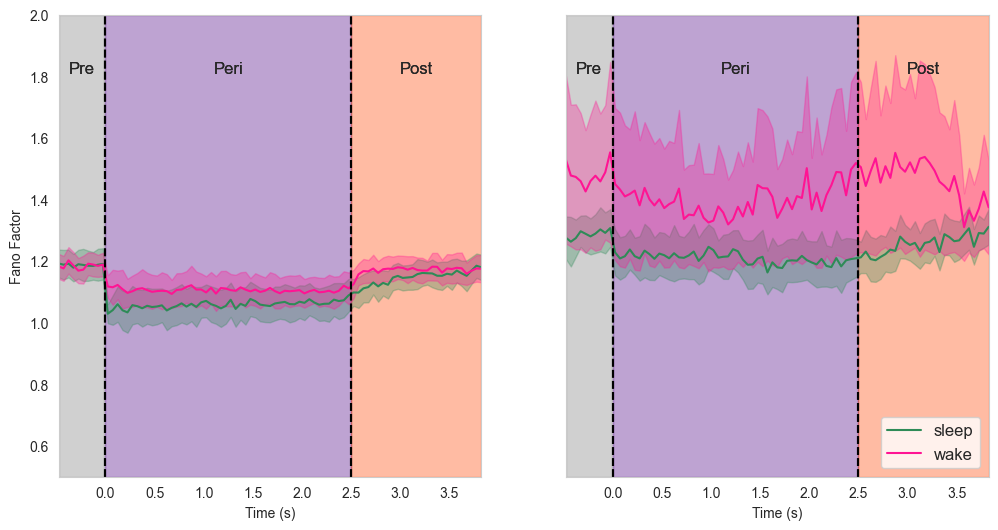

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_dynamics(df_final,
                         metric,
                         t_trial_centers,
                         colors,
                         axs,
                         regions=('low', 'high'),
                         states=('sleep', 'wake'), 
                         ylim=None, ylabel=None
                         ):
    """
    Generalized time-dynamics plotting function.

    Parameters
    ----------
    metric : str
        Name of metric (e.g., 'FANO', 'mean_FR', 'reliability', etc.)
    """

    groups = df_final.groupby(['State', 'Region'])

    metric_means = {}

    # -------------------------
    # Collect data
    # -------------------------
    for (state, region), group in groups:
        if state not in states:
            continue

        key_mean = f'{metric}_mean'
        if key_mean not in group:
            raise ValueError(f"{metric} not found in df_final")

        metric_means.setdefault(region, {})[state] = np.array(group[key_mean].values[0])

    # -------------------------
    # Plot traces
    # -------------------------
    for (state, region), group in groups:
        if state  not in states:
            continue

        ax = axs[0] if region == regions[0] else axs[1]

        mean = np.array(group[f'{metric}_mean'].values[0])
        sem  = np.array(group[f'{metric}_sem'].values[0])

        ax.plot(t_trial_centers, mean,
                label=state,
                color=colors[state])

        ax.fill_between(t_trial_centers,
                        mean - sem,
                        mean + sem,
                        alpha=0.3,
                        color=colors[state])

        # stimulus markers
        ax.axvline(x=0, color='k', linestyle='--')
        ax.axvline(x=2.5, color='k', linestyle='--')

        ax.set_xlim([t_trial_centers[0], t_trial_centers[-1]])

        ax.set_xlabel('Time (s)')

        # labels
        if ax == axs[0]:
            if ylabel is None:
                ax.set_ylabel(metric)
            else:
                ax.set_ylabel(ylabel)
        else:
            ax.set_ylabel('')
            ax.set_yticks([])
            ax.legend(fontsize=12, loc='lower right')
        
        if ylim is not None:
            ax.set_ylim(ylim)
        ax.grid(False)

        # -------------------------
        # Shade time windows
        # -------------------------
        if time_windows_dict is not None:
            for label, (start, end) in time_windows_dict.items():
                start = max(start, t_trial_centers[0])
                end   = min(end, t_trial_centers[-1])

                ax.axvspan(start, end,
                           color=window_colors[label],
                           alpha=0.2,
                           zorder=0)

                if name_mapping is not None:
                    ax.text((start + end) / 2,
                            ax.get_ylim()[1]*0.9,
                            name_mapping[label],
                            ha='center',
                            va='bottom',
                            fontsize=12)

    # -------------------------
    # Print window stats
    # -------------------------
    if time_windows_dict is not None:
        for i, region in enumerate(regions):
            if not all(s in metric_means.get(region, {}) for s in states):
                continue

            m1 = metric_means[region][states[0]]
            m2 = metric_means[region][states[1]]

            for label, (start, end) in time_windows_dict.items():
                start = max(start, t_trial_centers[0])
                end   = min(end, t_trial_centers[-1])

                mask = (t_trial_centers >= start) & (t_trial_centers < end)
                if not np.any(mask):
                    continue

                mean1 = np.nanmean(m1[mask])
                mean2 = np.nanmean(m2[mask])

                std1 = np.nanstd(m1[mask])
                std2 = np.nanstd(m2[mask])

                print(f"{region} {label}: "
                      f"{states[0]}={mean1:.3f}±{std1:.3f}, "
                      f"{states[1]}={mean2:.3f}±{std2:.3f}")
                

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

plot_metric_dynamics(df_final,
                     metric='FANO',
                     t_trial_centers=t_trial_centers,
                     colors=colors,
                     axs=axs, ylim=[0.5,2], ylabel='Fano Factor')

low Spontaneous: sleep=4.595±0.021, wake=7.270±0.058
low Sound: sleep=5.974±0.920, wake=8.474±0.804
low Persistence: sleep=4.496±0.313, wake=7.294±0.255
high Spontaneous: sleep=4.103±0.036, wake=5.241±0.049
high Sound: sleep=4.130±0.208, wake=5.600±0.262
high Persistence: sleep=3.889±0.084, wake=5.297±0.095


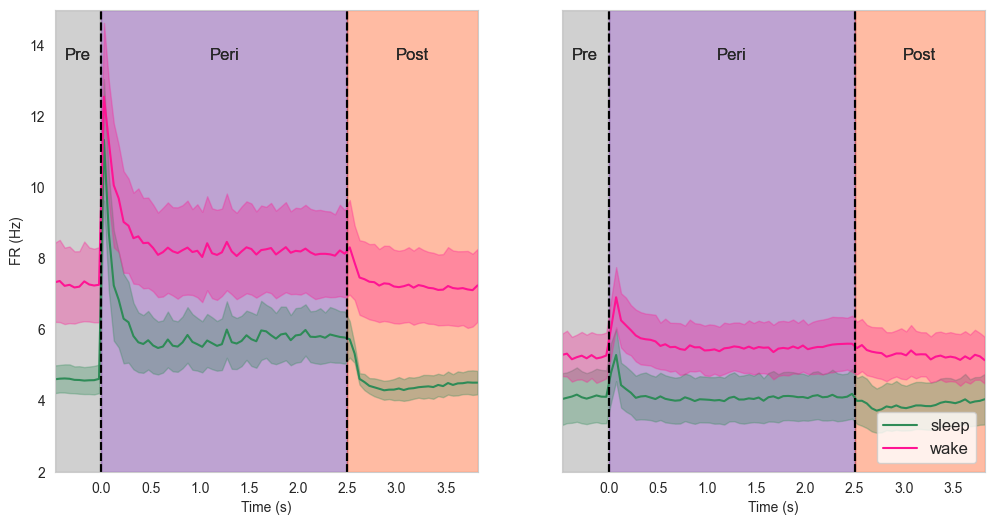

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

plot_metric_dynamics(df_final,
                     metric='mean_FR',
                     t_trial_centers=t_trial_centers,
                     colors=colors,
                     axs=axs, ylim=[2, 15], ylabel='FR (Hz)')

low Spontaneous: sleep=0.307±0.002, wake=0.454±0.006
low Sound: sleep=0.347±0.045, wake=0.488±0.046
low Persistence: sleep=0.285±0.015, wake=0.451±0.010
high Spontaneous: sleep=0.313±0.005, wake=0.475±0.015
high Sound: sleep=0.292±0.012, wake=0.453±0.025
high Persistence: sleep=0.286±0.011, wake=0.448±0.031


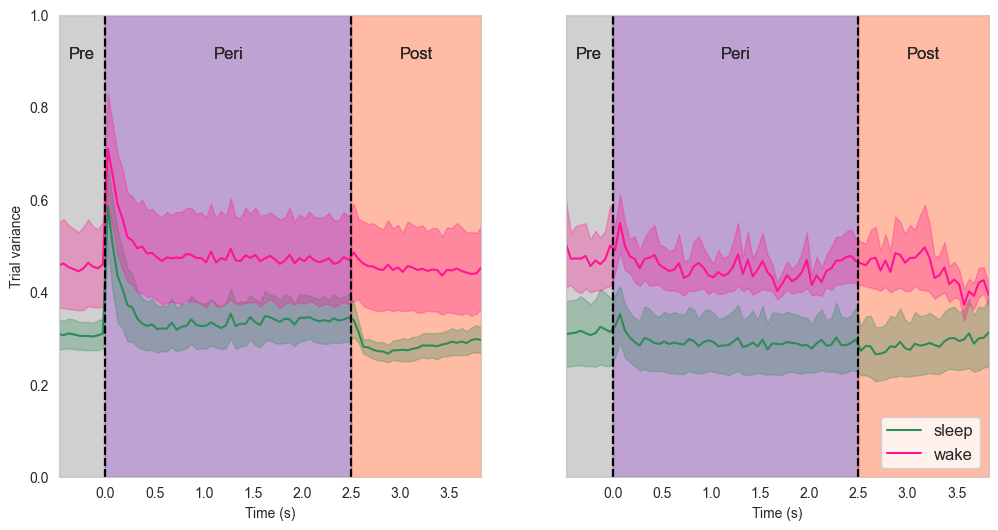

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

plot_metric_dynamics(df_final,
                     metric='trial_var',
                     t_trial_centers=t_trial_centers,
                     colors=colors,
                     axs=axs, ylim=[0, 1], ylabel='Trial variance')

## Persistent cells

### Find Persistent cells with significant FR in post- compared to pre-stimulus

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def compute_romo_cells(df_agg,
                       t_trial_centers,
                       spikes_col='Spikes',
                       group_cols=['Subject','Date','State','SoundType','Region']):
    """
    Identify neurons with significantly higher firing in Persistence vs Spontaneous per SoundType.

    Uses:
        - Wilcoxon signed-rank test (paired, non-parametric)

    Returns per group:
        - FR_windows      : dict of (T, N) arrays
        - pvals           : raw p-values (N,)
        - romo_cells      : boolean mask (N,)
        - effect_size     : mean difference (Persistence - Spontaneous) per neuron
        - n_romo_cells    : count
        - frac_romo_cells : fraction
    """

    rows = []

    for _, row in df_agg.iterrows():
        spikes = row[spikes_col]  # (T, N, B)
        T, N, B = spikes.shape

        # ---------------------------------
        # Compute FR per trial per neuron per window
        # ---------------------------------
        fr_windows = {}
        for win_name, (t_start, t_end) in time_windows_dict.items():
            mask = (t_trial_centers >= t_start) & (t_trial_centers < t_end)

            if not np.any(mask):
                raise ValueError(f"No time bins found for window {win_name}")

            fr_windows[win_name] = spikes[:, :, mask].mean(axis=-1)  # (T, N)

        spont = fr_windows['Spontaneous']
        pers  = fr_windows['Persistence']

        # ---------------------------------
        # Per-neuron stats
        # ---------------------------------
        pvals = np.full(N, np.nan)
        effect_size = np.full(N, np.nan)

        for n in range(N):
            x = spont[:, n]
            y = pers[:, n]

            # remove NaNs
            valid = ~np.isnan(x) & ~np.isnan(y)
            x = x[valid]
            y = y[valid]

            if len(x) < 2:
                continue

            # compute effect size (mean difference)
            effect_size[n] = np.mean(y - x)

            # if no variability → skip
            if np.allclose(x, y):
                continue

            try:
                stat, pval = wilcoxon(y, x, mode='approx', alternative='greater')
                pvals[n] = pval
            except ValueError:
                # happens if all differences are zero or invalid
                continue


        # ---------------------------------
        # Store results
        # ---------------------------------
        meta = {col: row[col] for col in group_cols}
        meta.update({
            'FR_windows': fr_windows,
            'pvals': pvals,
            'effect_size': effect_size,
            'n_neurons': N,
            'n_trials': T
        })

        rows.append(meta)

    return pd.DataFrame(rows)

df_romo_sound = compute_romo_cells(df_agg, t_trial_centers)

D:\BarakH_codes\SpikeInterface\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


In [14]:
df_romo_sound.head()

,Subject,Date,State,SoundType,Region,FR_windows,pvals,effect_size,n_neurons,n_trials
0,C9,20240312,wake,101,low,"{'Spontaneous': [[0.0, 0.0, 0.0, 6.00000000000...","[0.7728010467733335, 0.3465139595501473, 0.872...","[-0.2644364794902433, -0.1513341298287543, -0....",81,93
1,C9,20240312,wake,101,high,"{'Spontaneous': [[6.000000000000002, 8.0000000...","[0.0028346092319185214, 0.2409975296378653, 0....","[0.6778176025487853, 0.516129032258065, -0.074...",118,93
2,C9,20240312,sleep,101,low,"{'Spontaneous': [[28.000000000000007, 2.000000...","[0.5264633431607353, 0.7326269462778389, 0.881...","[-0.3670634920634915, -0.6058201058201061, -0....",81,112
3,C9,20240312,sleep,101,high,"{'Spontaneous': [[0.0, 16.000000000000004, 2.0...","[0.014524940575512364, 0.1734507566734128, 0.6...","[0.49867724867724894, 0.49735449735449627, -0....",118,112
4,C9,20240312,wake,400,low,"{'Spontaneous': [[0.0, 0.0, 0.0, 2.00000000000...","[1.7141465826361543e-11, 2.6722972820293663e-0...","[2.305130818892285, 2.700645599728171, -0.6469...",81,109


In [15]:
from scipy.stats import combine_pvalues

def combine_across_sounds(df_romo_sound,
                         group_cols=['Subject','Date','State','Region'],
                         alpha=0.05):
    """
    Combine neuron-level p-values across sound conditions and identify significant neurons.

    This function aggregates statistical results across different sound types for each neuron,
    within each experimental grouping (e.g., Subject × Date × State × Region).

    Processing steps per group:
    1. Stack p-values across sound types for each neuron.
    2. Combine p-values across sounds using Fisher's method (scipy.stats.combine_pvalues).
    3. FDR correction (Benjamini–Hochberg) across neurons.
    4. Classify neurons as significant ("romo cells") based on FDR-corrected p-values.

    Parameters
    ----------
    df_romo_sound : pandas.DataFrame
        Input dataframe containing per-sound statistical results.
        Must include:
        - 'pvals': array-like of shape (n_neurons,) per row (one row per sound condition)
        - columns specified in `group_cols` for grouping

    group_cols : list of str, default ['Subject','Date','State','Region']
        Columns used to group the data before combining across sounds.

    alpha : float, default 0.05
        Significance level used for FDR correction.

    Returns
    -------
    pandas.DataFrame
        One row per group with the following fields:
        - group metadata (from `group_cols`)
        - 'pvals_combined': array of combined p-values per neuron
        - 'pvals_fdr': array of FDR-corrected p-values per neuron
        - 'romo_cells': boolean array indicating significant neurons
        - 'n_romo_cells': number of significant neurons
        - 'frac_romo_cells': fraction of significant neurons
        - 'n_neurons': total number of neurons


    """
    
    rows = []

    for key, grp in df_romo_sound.groupby(group_cols):

        # stack p-values → (n_sounds, n_neurons)
        pval_stack = np.stack(grp['pvals'].values)

        N = pval_stack.shape[1]

        pvals_combined = np.full(N, np.nan)

        for n in range(N):
            pvals_n = pval_stack[:, n]

            # remove NaNs
            pvals_n = pvals_n[~np.isnan(pvals_n)]

            if len(pvals_n) == 0:
                continue

            # combine across sounds
            stat, p_comb = combine_pvalues(pvals_n, method='fisher')
            pvals_combined[n] = p_comb

        # ---------------------------------
        # FDR across neurons
        # ---------------------------------
        pvals_fdr = np.full(N, np.nan)
        romo_cells = np.zeros(N, dtype=bool)

        valid = ~np.isnan(pvals_combined)
        if np.sum(valid) > 0:
            rej, p_corr, _, _ = multipletests(
                pvals_combined[valid],
                alpha=alpha,
                method='fdr_bh'
            )
            pvals_fdr[valid] = p_corr
            romo_cells[valid] = rej

        # summary
        n_romo = np.sum(romo_cells)
        frac_romo = n_romo / N if N > 0 else np.nan

        # unpack metadata
        if isinstance(key, tuple):
            meta = dict(zip(group_cols, key))
        else:
            meta = {group_cols[0]: key}

        meta.update({
            'pvals_combined': pvals_combined,
            'pvals_fdr': pvals_fdr,
            'romo_cells': romo_cells,
            'n_romo_cells': n_romo,
            'frac_romo_cells': frac_romo,
            'n_neurons': N
        })

        rows.append(meta)

    return pd.DataFrame(rows)

df_romo = combine_across_sounds(df_romo_sound)

In [16]:
df_romo

,Subject,Date,State,Region,pvals_combined,pvals_fdr,romo_cells,n_romo_cells,frac_romo_cells,n_neurons
0,C11,20240911,sleep,high,"[0.010541022274185352, 0.10888424846334435, 0....","[0.047434600233834084, 0.24390723206757042, 0....","[True, False, False, False, True, True, True, ...",26,0.222222,117
1,C11,20240911,sleep,low,"[0.48315682560173845, 0.19878250259236765, 0.5...","[0.9999999999999999, 0.6405213972420736, 0.999...","[False, False, False, False, True, True, False...",17,0.146552,116
2,C11,20240911,wake,high,"[0.06268955678163018, 0.46136733731748303, 0.4...","[0.22226297404396156, 0.6033169832610853, 0.60...","[False, False, False, False, False, True, Fals...",17,0.145299,117
3,C11,20240911,wake,low,"[0.005601651623223339, 0.7935484261006045, 2.4...","[0.012495992082575142, 0.9588710148715638, 2.3...","[True, False, True, True, True, True, False, T...",58,0.500000,116
4,C11,20240917,sleep,high,"[0.005112511002628291, 0.005671415776899551, 0...","[0.033961680231745076, 0.035162777816777215, 0...","[True, True, True, False, False, False, False,...",17,0.182796,93
5,C11,20240917,sleep,low,"[0.007247031780658104, 0.08329472137915182, 0....","[0.05858017356031967, 0.37524739334789703, 0.4...","[False, False, False, False, False, False, Fal...",8,0.082474,97
6,C11,20240917,wake,high,"[0.17584170377117161, 0.33647958405770595, 0.5...","[0.3803088011795107, 0.530383073175706, 0.6584...","[False, False, False, False, False, False, Fal...",4,0.043011,93
7,C11,20240917,wake,low,"[0.49864519052513645, 0.005860929708395168, 0....","[0.7113026982490918, 0.017227581264070646, 0.1...","[False, True, False, False, False, False, True...",38,0.391753,97
8,C12,20241007,sleep,high,"[0.05691145499561735, 0.1392364285314512, 0.12...","[0.1778482968613042, 0.21755691958039253, 0.21...","[False, False, False, False, False, True, Fals...",4,0.160000,25
9,C12,20241007,sleep,low,"[0.0015281417925168044, 0.008722258543972657, ...","[0.0027166965200298744, 0.012686921518505683, ...","[True, True, False, True, True, True, True, Tr...",24,0.750000,32


### Linear mixed model: Fraction of persistent cells vs state*region 

In [17]:
import statsmodels.formula.api as smf

# make sure categorical
df_romo['State'] = df_romo['State'].astype('category')
df_romo['Region'] = df_romo['Region'].astype('category')
df_romo['Subject_Date'] = df_romo['Subject'].astype(str) + '_' + df_romo['Date'].astype(str)

# LMM
model = smf.mixedlm(
    "frac_romo_cells ~ State * Region",
    df_romo,
    groups=df_romo["Subject"],
    vc_formula={"session": "0 + C(Subject_Date)"}
)

result = model.fit()
print(result.summary())

                Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    frac_romo_cells
No. Observations:    44         Method:                REML           
No. Groups:          5          Scale:                 0.0244         
Min. group size:     8          Log-Likelihood:        10.1657        
Max. group size:     12         Converged:             Yes            
Mean group size:     8.8                                              
----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                    0.215    0.051  4.221 0.000  0.115  0.314
State[T.wake]               -0.066    0.067 -0.996 0.319 -0.197  0.064
Region[T.low]                0.241    0.067  3.614 0.000  0.110  0.371
State[T.wake]:Region[T.low] -0.115    0.094 -1.218 0.223 -0.299  0.070
session Var            

D:\BarakH_codes\SpikeInterface\venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [18]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

def compute_contrast(L, params, cov):
    est = np.dot(L, params)
    se  = np.sqrt(np.dot(L, np.dot(cov, L)))
    z   = est / se
    p   = 2 * (1 - norm.cdf(np.abs(z)))

    # 95% CI
    ci_low  = est - 1.96 * se
    ci_high = est + 1.96 * se

    return est, se, z, p, ci_low, ci_high

def extract_contrasts(result):
    params = result.fe_params
    cov = result.cov_params().loc[params.index, params.index]

    def make_L(names):
        L = np.zeros(len(params))
        for k, v in names.items():
            if k in params.index:
                L[params.index.get_loc(k)] = v
        return L

    contrasts = {
        "State (wake vs sleep) | HIGH": make_L({"State[T.wake]": 1}),
        "State (wake vs sleep) | LOW": make_L({
            "State[T.wake]": 1,
            "State[T.wake]:Region[T.low]": 1
        }),
        "Region (low vs high) | SLEEP": make_L({"Region[T.low]": 1}),
        "Region (low vs high) | WAKE": make_L({
            "Region[T.low]": 1,
            "State[T.wake]:Region[T.low]": 1
        })
    }

    rows = []
    for name, L in contrasts.items():
        est, se, z, p, ci_low, ci_high = compute_contrast(L, params, cov)
        rows.append({
            "contrast": name,
            "estimate": est,
            "se": se,
            "z": z,
            "p": p,
            "ci_low": ci_low,
            "ci_high": ci_high
        })

    df_contrasts = pd.DataFrame(rows)

    # FDR
    rej, pvals_corr, _, _ = multipletests(df_contrasts["p"], method='fdr_bh')
    df_contrasts["p_fdr"] = pvals_corr
    df_contrasts["significant"] = rej

    return df_contrasts

df_contrasts = extract_contrasts(result)
print(df_contrasts)

                       contrast  estimate        se         z         p  \
0  State (wake vs sleep) | HIGH -0.066403  0.066643 -0.996402  0.319055   
1   State (wake vs sleep) | LOW -0.181162  0.066643 -2.718408  0.006560   
2  Region (low vs high) | SLEEP  0.240833  0.066643  3.613789  0.000302   
3   Region (low vs high) | WAKE  0.126074  0.066643  1.891782  0.058520   

     ci_low   ci_high     p_fdr  significant  
0 -0.197023  0.064217  0.319055        False  
1 -0.311782 -0.050542  0.013119         True  
2  0.110213  0.371453  0.001207         True  
3 -0.004546  0.256693  0.078027        False  


Neurons were classified as persistence-selective if they exhibited significantly elevated activity during the persistence window. To assess persistence while accounting for stimulus variability, p-values across sound conditions were combined per neuron using Fisher’s method, yielding a single measure of persistence significance. Using this approach, the fraction of persistence-selective neurons remained strongly structured along the cortical hierarchy but exhibited more selective state dependence. A mixed-effects model (n=11 sessions) revealed that low (early) regions showed a significantly higher proportion of persistence neurons compared to high (late) regions during sleep (β = 0.24, 95% CI [0.11, 0.37], p = 0.001), with a similar trend during wake (β = 0.13, 95% CI [−0.005, 0.26], p = 0.078). In contrast, state-dependent modulation was only evident in low regions, where the fraction of persistence neurons was significantly reduced during wake compared to sleep (β = −0.18, 95% CI [−0.31, −0.05], p = 0.013), while no significant state effect was observed in high regions (p = 0.32). The interaction between state and region was not significant (p = 0.22).

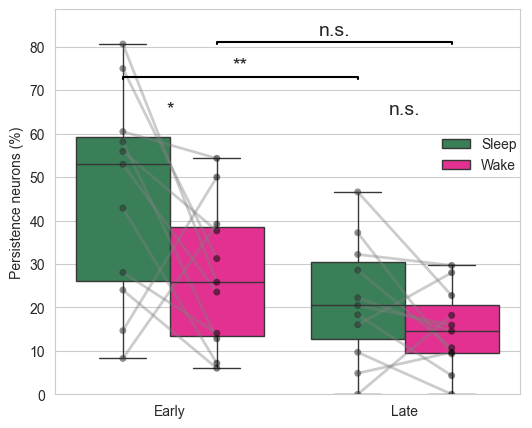

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_romo(ax, df, df_contrasts):

    df = df.copy()
    df["percent_romo"] = df["frac_romo_cells"] * 100
    df["Subject_Date"] = df["Subject"].astype(str) + "_" + df["Date"].astype(str)

    # collapse for pairing
    df_plot = (
        df.groupby(["Subject_Date", "State", "Region"])["percent_romo"]
          .mean()
          .reset_index()
    )

    order = ["low", "high"]
    hue_order = ["sleep", "wake"]

    # -----------------------------
    # Boxplot
    # -----------------------------
    sns.boxplot(
        data=df_plot,
        x="Region",
        y="percent_romo",
        hue="State",
        order=order,
        hue_order=hue_order,
        showfliers=False,
        palette=colors,
        ax=ax
    )

    # -----------------------------
    # Stripplot
    # -----------------------------
    sns.stripplot(
        data=df_plot,
        x="Region",
        y="percent_romo",
        hue="State",
        order=order,
        hue_order=hue_order,
        dodge=True,
        alpha=0.5,
        jitter=False,
        palette="dark:black",
        ax=ax
    )

    # -----------------------------
    # Paired lines
    # -----------------------------
    x_positions = {
        ("low", "sleep"): 0 - 0.2,
        ("low", "wake"):  0 + 0.2,
        ("high", "sleep"): 1 - 0.2,
        ("high", "wake"):  1 + 0.2
    }

    for (subj_date, region), subdf in df_plot.groupby(["Subject_Date", "Region"]):
        if set(subdf["State"]) != {"sleep", "wake"}:
            continue

        subdf = subdf.set_index("State")

        xs = [
            x_positions[(region, "sleep")],
            x_positions[(region, "wake")]
        ]

        ys = [
            subdf.loc["sleep", "percent_romo"],
            subdf.loc["wake", "percent_romo"]
        ]

        ax.plot(xs, ys, color="gray", alpha=0.4, linewidth=2)

    # -----------------------------
    # Significance stars
    # -----------------------------
    def get_star(p):
        if p < 0.001: return "***"
        elif p < 0.01: return "**"
        elif p < 0.05: return "*"
        else: return "n.s."

    ymax = df_plot["percent_romo"].max()

    # STATE comparisons (within region)
    p_low = df_contrasts.loc[
        df_contrasts["contrast"] == "State (wake vs sleep) | LOW", "p_fdr"
    ].values[0]

    p_high = df_contrasts.loc[
        df_contrasts["contrast"] == "State (wake vs sleep) | HIGH", "p_fdr"
    ].values[0]

    ax.text(0, ymax*0.8, get_star(p_low), ha='center', fontsize=14)
    ax.text(1, ymax*0.8, get_star(p_high), ha='center', fontsize=14)

    # -----------------------------
    # REGION brackets
    # -----------------------------
    def draw_bracket(x1, x2, y, h, text):
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
        ax.text((x1+x2)/2, y+h+0.5, text, ha='center', va='bottom', fontsize=14)

    # sleep bracket
    p_sleep = df_contrasts.loc[
        df_contrasts["contrast"] == "Region (low vs high) | SLEEP", "p_fdr"
    ].values[0]

    draw_bracket(-0.2, 0.8, ymax*0.9, 0.5, get_star(p_sleep))

    # wake bracket
    p_wake = df_contrasts.loc[
        df_contrasts["contrast"] == "Region (low vs high) | WAKE", "p_fdr"
    ].values[0]

    draw_bracket(0.2, 1.2, ymax*1, 0.5, get_star(p_wake))

    # -----------------------------
    # Labels
    # -----------------------------
    ax.set_ylabel("Persistence neurons (%)")
    ax.set_xlabel("")
    # plt.title("Persistence-selective neurons")

    ax.set_ylim(0, ymax + 8)

    ax.set_xticks(
    ticks=[0, 1],
    labels=[name_mapping['low'], name_mapping['high']]
    )
    
    # Clean legend
    handles, labels = plt.gca().get_legend_handles_labels()
    labels_capital = [label.capitalize() for label in labels]
    ax.legend(handles[:2], labels_capital[:2], bbox_to_anchor=(1.02, 0.7), loc='upper right', frameon=False)

fig, ax = plt.subplots(figsize=(6,5))
plot_romo(ax, df_romo, df_contrasts)

### Plotting: Example persistent units (from Figure 3)

Sound loaded successfully. Duration: 2.56 seconds
Sound loaded successfully. Duration: 2.56 seconds


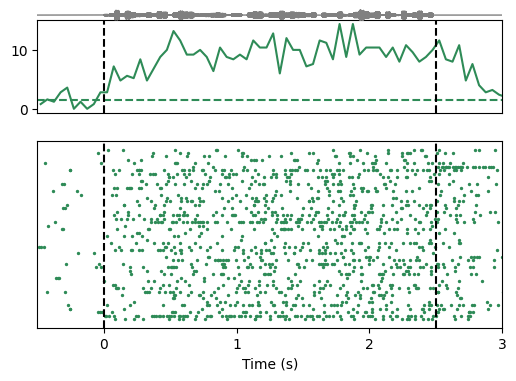

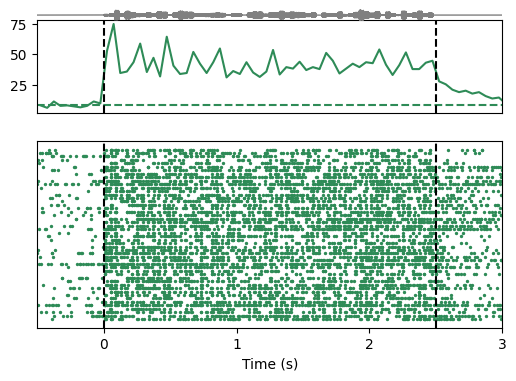

In [20]:
import pickle
import scipy.io
import matplotlib.pyplot as plt
plt.style.use('default')  # resets to pre-Seaborn/Matplotlib default

def load_sounwaveform(Sound_pick):
    Path_to_sounds = DATA_PATH + rf"\{Sound_pick}_sound.mat"

    # Load the sound data from the MAT file
    sound_data = scipy.io.loadmat(Path_to_sounds)
    sound_wave = sound_data['soundData']['soundwave'][0, 0].flatten()  # Extract the sound waveform
    sound_fs = 192000  # Sound sampling rate in Hz (192 kHz as mentioned)
    
    # Create a time vector for the sound (starting at 0)
    sound_duration = len(sound_wave) / sound_fs  # Duration in seconds
    sound_time = np.linspace(0, sound_duration, len(sound_wave))
    print(f"Sound loaded successfully. Duration: {sound_duration:.2f} seconds")
    
    buffer_sound_before = BUFFER_BEFORE_SEC * sound_fs
    buffer_sound_after = (BUFFER_AFTER_SEC - sound_duration) * sound_fs
    
    sound_wave_pad = np.pad(sound_wave, (int(buffer_sound_before), int(buffer_sound_after)), mode='constant')
    sound_time_pad = np.linspace(-BUFFER_BEFORE_SEC, BUFFER_AFTER_SEC, len(sound_wave_pad))
    return sound_wave_pad, sound_time_pad

def plot_units_persist(results, ax_psth, ax_raster, unit, sound, plot_titles=False):
    """
    Plot PSTH + raster for a given unit/sound from saved results.
    """
    if (unit, sound) not in results:
        print(f"No results stored for unit {unit}, sound {sound}")
        return

    r = results[(unit, sound)]

    # Unpack
    t_bins = r["t_bins"]
    mean_fr = r["mean_fr"]
    baseline = r["baseline"]
    clusters = r["clusters"]
    cluster_p_values = r["cluster_p_values"]
    stim_mask = r["stim_mask"]
    rasters = r["rasters"]

    # --- Plot ---

    # PSTH
    ax_psth.plot(t_bins, mean_fr, color=colors['sleep'])
    ax_psth.axhline(baseline, color=colors['sleep'], linestyle="--", label="baseline")
    ax_psth.axvline(0, color="k", linestyle="--")
    ax_psth.axvline(2.5, color="k", linestyle="--")
    
    if plot_titles:
        ax_psth.set_ylabel("FR (Hz)")
    # ax_psth.set_title(f"Unit {unit}, sound {sound}")
    # ax_psth.legend(frameon=False)
    ax_psth.set_xticks([])
    ax_psth.set_xlim([-0.5, 3.0])
    
    # Raster
    for trial_idx, spikes in enumerate(rasters):
        ax_raster.scatter(spikes, np.full_like(spikes, trial_idx),
                          s=2, color=colors['sleep'], rasterized=True)

    ax_raster.axvline(0, color="k", linestyle="--")
    ax_raster.axvline(2.5, color="k", linestyle="--")
    ax_raster.set_xlabel("Time (s)")
    ax_raster.set_ylabel("Trials")
    if not plot_titles:
        ax_raster.set_ylabel('')
        ax_raster.set_yticks([])

    ax_raster.set_xlim([-0.5, 3.0])
    ax_raster.set_xticks([0, 1, 2, 3])
    sound_wave, sound_time = load_sounwaveform(sound)
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    # Create an inset axis above ax_hist
    inset_ax = inset_axes(ax_psth, width="100%", height="30%", 
                          bbox_to_anchor=(0, 0.85, 1, 0.4), 
                          bbox_transform=ax_psth.transAxes, 
                          loc='center')
    
    # Plot the sound waveform in gray
    inset_ax.plot(sound_time, sound_wave, color='gray', linewidth=1)
    inset_ax.set_xlim([-0.5, 3.0])
    inset_ax.axis('off')  # Hide axis for a clean look
    
save_path_units = DATA_PATH + rf"\sig_units.pkl"

with open(save_path_units, "rb") as f:
    results_units = pickle.load(f)

fig, (ax_psth, ax_raster) = plt.subplots(
    2, 1, figsize=(6, 4), gridspec_kw={'height_ratios':[1,2]}
)
plot_units_persist(results_units, ax_psth, ax_raster, 214, 400)

fig1, (ax_psth, ax_raster) = plt.subplots(
    2, 1, figsize=(6, 4), gridspec_kw={'height_ratios':[1,2]}
)
plot_units_persist(results_units, ax_psth, ax_raster, 334, 400)

### Remove persistent cells from main df

In [21]:
import numpy as np
import pandas as pd

def remove_romo_cells(df, df_romo, spikes_col='Spikes_matrix',
                      group_cols=['Subject','Date','State','Region']):
    """
    Remove romo neurons from the per-trial spike matrices in df
    based on df_romo tagging.
    
    Output: new df where the romo neurons are removed.
    """
    df_new = df.copy()

    for idx, row in df_romo.iterrows():
        condition = {col: row[col] for col in group_cols}
        romo_cells = row['romo_cells']  # boolean array, True = romo

        if not np.any(romo_cells):
            continue  # skip if no romo cells

        # select rows in df matching the condition
        mask = np.ones(len(df_new), dtype=bool)
        for col, val in condition.items():
            mask &= (df_new[col] == val)
        df_sel = df_new[mask]

        # remove romo neurons from Spikes_matrix in selected rows
        for i in df_sel.index:
            spikes = df_new.at[i, spikes_col]  # shape: (n_neurons, n_time_bins)
            df_new.at[i, spikes_col] = spikes[~romo_cells, :]  # keep non-romo neurons

    return df_new

df_no_romo = remove_romo_cells(df, df_romo)

### Model without persistent cells

In [22]:
ROMO_analysis = False  ## Only change to true if you wish to re-run the models

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def train_model_per_sound(df, state, region, t_trial, neuron_indices=None):
    df_filtered = df[(df['State'] == state) & (df['Region'] == region)]
    
    spike_matrices = np.array(df_filtered['Spikes_matrix'].tolist())  
    sound_labels = np.array(df_filtered['SoundType'])
    
    if neuron_indices is not None:
        spike_matrices = spike_matrices[:, neuron_indices, :]
        
    sound_types = sorted(np.unique(sound_labels))
    n_trials, n_neurons, n_time_bins = spike_matrices.shape
    
    models = {sound: {} for sound in sound_types}
    coefs = {sound: {} for sound in sound_types}
    cross_time_acc = {sound: np.zeros((n_time_bins, n_time_bins)) for sound in sound_types}
    scalers = {sound: {} for sound in sound_types}  # Store scalers for later use
    per_trial_preds = {sound: {} for sound in sound_types}
    corr_mat = {sound: np.zeros((n_time_bins, n_time_bins)) for sound in sound_types}

    for target_sound in sound_types:
        # print(f"Training for sound: {target_sound}")

        for i in range(n_time_bins):
            X = spike_matrices[:, :, i]
            y = (sound_labels == target_sound).astype(int)

            pos_indices = np.where(y == 1)[0]
            neg_indices = np.where(y == 0)[0]
            neg_sampled = np.random.choice(neg_indices, size=len(pos_indices), replace=False)

            balanced_indices = np.concatenate([pos_indices, neg_sampled])
            X_balanced = X[balanced_indices]
            y_balanced = y[balanced_indices]

            X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X_balanced, y_balanced, np.arange(len(y_balanced)), test_size=0.2, random_state=42)

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            model = LogisticRegression(solver='lbfgs', max_iter=500)
            model.fit(X_train_scaled, y_train)
            models[target_sound][t_trial[i]] = model
            coefs[target_sound][t_trial[i]] = model.coef_.flatten()
            scalers[target_sound][t_trial[i]] = scaler  # Save the scaler
            per_trial_preds[target_sound][t_trial[i]] = {'true': y_test, 'pred': model.predict(X_test_scaled), 'index': idx_test}
            
            for j in range(n_time_bins):
                X_balanced_test = spike_matrices[:, :, j][balanced_indices]
                _, X_test_time, _, y_test_time = train_test_split(X_balanced_test, y_balanced, test_size=0.2, random_state=42)

                X_test_time_scaled = scaler.transform(X_test_time)

                y_pred = model.predict(X_test_time_scaled)
                acc = accuracy_score(y_test_time, y_pred)
                cross_time_acc[target_sound][i, j] = acc
            
    return models, coefs, scalers, per_trial_preds, cross_time_acc

def run_analysis(df, subject_id, cur_date, t_trial):
    for state in ['sleep', 'wake']:
        for region in ['low', 'high']:
            print(f"\nProcessing {state} - {region}...")
            
            save_folder = "GLM_results_romo"
            
            os.makedirs(DATA_PATH + rf"\{save_folder}", exist_ok=True)
            save_path = DATA_PATH + rf"\{save_folder}\glm_results_{subject_id}_{cur_date}_{state}_{region}.pkl"
                                        
            models, coefs, scalers, per_trial_preds, cross_time_acc = train_model_per_sound(df, state, region, t_trial, None)
            
            # Save everything using pickle
            with open(save_path, "wb") as f:
                pickle.dump((models, coefs, scalers, per_trial_preds, cross_time_acc), f)

if ROMO_analysis:
    for subject_id in subjects_data.keys():
        for i, cur_date in enumerate(subjects_data[subject_id]['folders_dates_to_collect']):
            print(f'Processing {subject_id} - {cur_date}...')
            high_ch = subjects_data[subject_id]['high_ch']
            low_ch = subjects_data[subject_id]['low_ch']
            
            cur_df = df_no_romo.copy()
            
            cur_df = cur_df[(cur_df['Date'] == int(cur_date)) & (cur_df['Subject'] == subject_id)]
            t_hist = t_trial[:-1] + np.mean(np.diff(t_trial))/2
            run_analysis(cur_df, subject_id, cur_date, t_hist)

In [24]:
import pickle

# Nested dictionary to collect all data
all_glm_data = {}

for subject_id in subjects_data.keys():
    all_glm_data[subject_id] = {}
    for i, cur_date in enumerate(subjects_data[subject_id]['folders_dates_to_collect']):
        all_glm_data[subject_id][cur_date] = {}
        for state in ['sleep', 'wake']:
            all_glm_data[subject_id][cur_date][state] = {}
            for region in ['low', 'high']:
                save_folder = "GLM_results_romo"
                save_path = DATA_PATH + rf"\{save_folder}\glm_results_{subject_id}_{cur_date}_{state}_{region}.pkl"

                with open(save_path, 'rb') as f:
                    models, coefs, scalers, per_trial_preds, cross_time_acc = pickle.load(f)

                # Store in the nested dictionary
                all_glm_data[subject_id][cur_date][state][region] = {
                    'models': models,
                    'coefs': coefs,
                    'scalers': scalers,
                    'per_trial_preds': per_trial_preds,
                    'cross_time_acc': cross_time_acc
                }

In [25]:
def extract_mean_std_acc(all_glm_data, n_sounds):
    cross_time_acc_summary = {}  # [state][region][sound_type] = {'mean': ..., 'std': ...}

    for state in ['sleep', 'wake']:
        cross_time_acc_summary[state] = {}
    
        for region in ['low', 'high']:
            # Will collect per-subject averaged cross_time_acc (across dates)
            per_subject_averages = []
    
            for subject_id in all_glm_data:
                # Collect per-date cross_time_accs for this subject
                per_date_sounds = []
    
                for cur_date in all_glm_data[subject_id]:
                    acc = all_glm_data[subject_id][cur_date][state][region]['cross_time_acc']
                    per_date_sounds.append(acc)
    
                # Compute per-sound-type mean over dates (per subject)
                per_sound_mean = []
    
                for i, sound in enumerate(n_sounds):
                    matrices = [per_date[sound] for per_date in per_date_sounds]
                    stacked = np.stack(matrices)  # shape: (n_dates, time, time)
                    mean_matrix = np.mean(stacked, axis=0)  # mean over dates
                    per_sound_mean.append(mean_matrix)
    
                per_subject_averages.append(per_sound_mean)
    
            # Transpose the list-of-lists to per-sound aggregation
            per_subject_averages = np.array(per_subject_averages)  # shape: (n_subjects, n_sounds, time, time)
    
            cross_time_acc_summary[state][region] = {}
    
            for i, sound in enumerate(n_sounds):  # for each sound type
                sound_data = per_subject_averages[:, i, :, :]  # shape: (n_subjects, time, time)
                mean = np.mean(sound_data, axis=0)
                std = np.std(sound_data, axis=0)
    
                cross_time_acc_summary[state][region][f'{sound}'] = {
                    'mean': mean,
                    'std': std
                }
    return cross_time_acc_summary

SoundTypes_model = [101, 400, 1300, 1402]
mean_std_time_acc = extract_mean_std_acc(all_glm_data, SoundTypes_model)

1.6878758390959092e-09
2.473844368466871e-06
4.696458777431189e-10
2.3215617761529472e-07


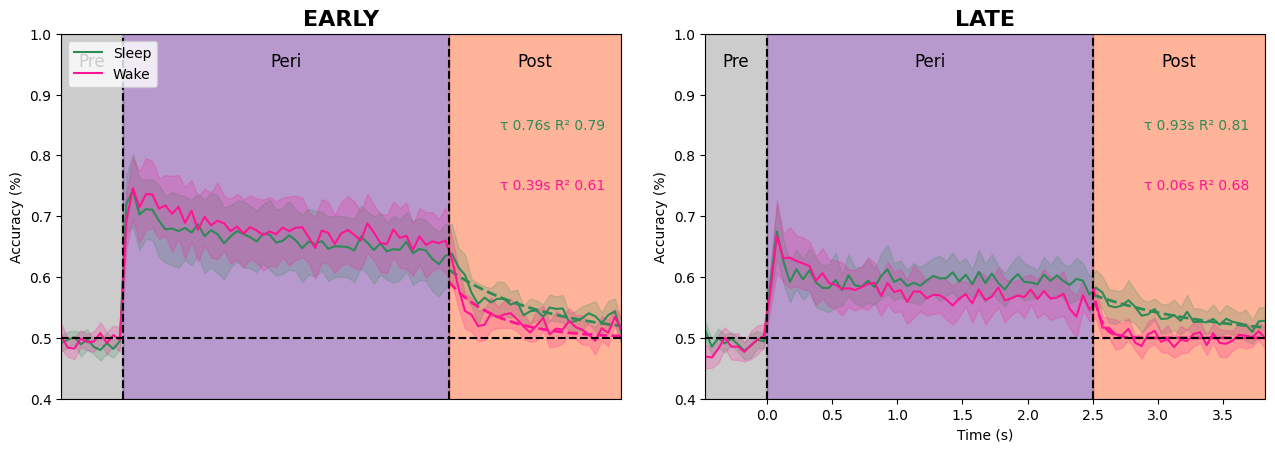

In [26]:
from scipy.optimize import curve_fit

def exp_decay(t, A, tau):
    C = 0.5
    return A * np.exp(-t / tau) + C

def general_decay(t, A, tau, beta):
    return A * np.exp(-(t / tau) ** beta) + 0.5

def power_law_decay(t, A, k):
    return A * (t + 1)**(-k) + 0.5

def multi_exp_decay(t, A1, tau1, A2, tau2):
    return A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2) + 0.5

def plot_avg_accuracy_by_state(axs, cross_time_acc_summary, time_bins):
    states = ['sleep', 'wake']
    regions = ['low', 'high']

    for col_idx, region in enumerate(regions):
        ax = axs[col_idx]

        for ind_state, state in enumerate(states):
            sound_data = cross_time_acc_summary[state][region]

            # Collect all diagonals
            means = [np.diag(acc['mean']) for acc in sound_data.values()]
            stds  = [np.diag(acc['std'])  for acc in sound_data.values()]

            mean_avg = np.mean(means, axis=0)
            std_avg = np.sqrt(np.mean(np.square(stds), axis=0)) / np.sqrt(len(subjects_data))
            # std_avg = np.sqrt(np.mean(np.square(stds), axis=0))

            ax.plot(time_bins, mean_avg, label=state.title(), color=colors[state])
            ax.fill_between(time_bins, mean_avg - std_avg, mean_avg + std_avg,
                            color=colors[state], alpha=0.2)
            
            mask = (time_bins >= time_bins[0]) & (time_bins <= time_bins[-1])

            # --- Tau fitting section ---
            last_label = 'Persistence'
            start_tau, end_tau = time_windows_dict[last_label]
            if start_tau == -np.Inf:
                start_tau = time_bins[0]
            elif start_tau == np.Inf:
                start_tau = time_bins[-1]

            # Get time and accuracy values within the last window
            mask = (time_bins >= start_tau) & (time_bins <= end_tau)
            time_pres = time_bins[mask]
            t_decay = time_pres - start_tau  # start at t=0 for fitting
            y_decay = mean_avg[mask]

            # Fit the exponential decay
            try:
                y_start = y_decay[0]
                y_end = y_decay[-1]
                # popt, _ = curve_fit(exp_decay, t_decay, y_decay, p0=[y_start-y_end, 0.5, y_end])
                # A, tau, C = popt
                popt, _ = curve_fit(exp_decay, t_decay, y_decay, p0=[y_start-y_end, 0.5])
                A, tau = popt

                # Plot the fitted curve
                t_fit = np.linspace(0, t_decay[-1], 100)
                y_fit = exp_decay(t_fit, *popt)
                ax.plot(t_fit + start_tau, y_fit, '--', color=colors[state], lw=2)

                from sklearn.metrics import r2_score
                y_pred = exp_decay(t_decay, *popt)
                r2 = r2_score(y_decay, y_pred)

                from scipy.stats import t
                n = len(y_decay)
                k = len(popt)
                t_stat = np.sqrt(r2 / (1 - r2) * (n - k - 1))
                pval = 2 * (1 - t.cdf(t_stat, df=n - k - 1))
                print(pval)

                tau_text = f"τ {tau:.2f}s R² {r2:.2f}"


                # Annotate tau on the plot
                ax.text(end_tau-0.2, 0.85 - ind_state * 0.1, tau_text, color=colors[state],va='center', ha='right')
            except RuntimeError:
                print(f"Fit failed for {state} - {region}")

        ax.set_ylim(0.4, 1)
        ax.axhline(y=0.5, linestyle='--', color='k')
        ax.axvline(x=0, linestyle='--', color='k')
        ax.axvline(x=2.5, linestyle='--', color='k')
        ax.set_xlim(time_bins[0], time_bins[-1])

        for label, (start, end) in time_windows_dict.items():
            if start < time_bins[0]: start = time_bins[0]
            if end > time_bins[-1]: end = time_bins[-1]
            ax.axvspan(start, end, color=window_colors[label], alpha=0.4, zorder=0)
            ax.text((start + end) / 2, 0.97, name_mapping[label], ha='center', va='top', fontsize=12, alpha=1)

        ax.grid(False)

        # if col_idx == 0:
        ax.set_ylabel('Accuracy (%)')
        # else:
        #     ax.set_yticks([])
        ax.set_title(f'{name_mapping[region].upper()}', fontsize=16, weight='bold')

        # for spine in ax.spines.values():
        #     spine.set_linewidth(6)
        #     spine.set_color(colors[region])

        if col_idx == 1:        
            ax.set_xlabel("Time (s)")
        else:
            ax.set_xticks([])
            ax.legend(loc='upper left')
            

fig2, axs2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.subplots_adjust(left=0.07, right=0.93, top=0.88, bottom=0.15, wspace=0.15)
t_hist = t_trial[:-1] + np.mean(np.diff(t_trial))/2
plot_avg_accuracy_by_state(axs2, mean_std_time_acc, t_hist)

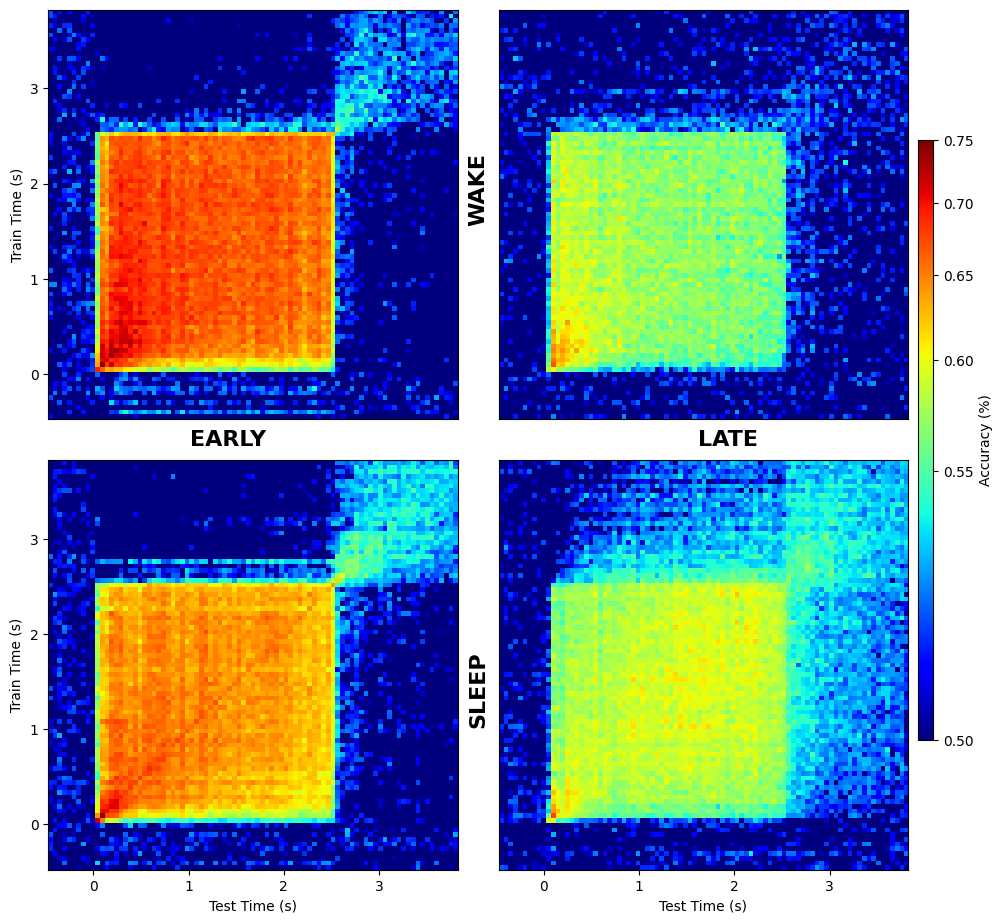

In [27]:
from matplotlib.colors import PowerNorm

def plot_heatmap_accuracy(axs, cross_time_acc_summary, time_bins):
    regions = ['low', 'high']
    states = ['wake', 'sleep']

    # Loop through regions (rows) and states (columns)
    for col_idx, region in enumerate(regions):
        for row_idx, state in enumerate(states):
            ax = axs[row_idx][col_idx]
            sound_data = cross_time_acc_summary[state][region]
            sound_means = [acc['mean'] for acc in sound_data.values()]
            mean_acc = np.mean(sound_means, axis=0)  # average over sounds
            
            norm = PowerNorm(gamma=0.5, vmin=0.5, vmax=0.75)  # boosts contrast in lower range

            im = ax.imshow(mean_acc, aspect='auto', origin='lower',
                extent=[time_bins[0], time_bins[-1], time_bins[0], time_bins[-1]],
                cmap='jet', norm=norm)
            ax.set_xticks([0, 1, 2, 3])
            ax.set_yticks([0, 1, 2, 3])

            if row_idx == 1:
                ax.set_xlabel('Test Time (s)')
            else:
                ax.set_xticks([])

            if col_idx == 0:
                ax.set_ylabel('Train Time (s)')
            else:
                ax.set_yticks([])

            ax.grid(False)
            ax.set_aspect('equal', adjustable='box')

            # ax.spines['top'].set_color(colors[region])
            # ax.spines['left'].set_color(colors[region])
            # ax.spines['bottom'].set_color(colors[state])
            # ax.spines['right'].set_color(colors[state])
            # # Set frame (spine) colors
            # for spine in ax.spines.values():
            #     spine.set_linewidth(6)

    return im  # so we can add colorbar

fig3, axs3 = plt.subplots(2, 2, figsize=(10, 10))
fig3.subplots_adjust(left=0.07, right=0.93, top=0.93, bottom=0.07, hspace=0.1, wspace=0.1)

im = plot_heatmap_accuracy(axs3, mean_std_time_acc, t_hist)

fig3.text(0.5, 0.75, 'WAKE', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
fig3.text(0.5, 0.25, 'SLEEP', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
fig3.text(0.25, 0.5, 'EARLY', ha='center', va='center', fontsize=16, weight='bold', rotation=0)
fig3.text(0.75, 0.5, 'LATE', ha='center', va='center', fontsize=16, weight='bold', rotation=0)

# Add shared colorbar
cbar_ax = fig3.add_axes([0.94, 0.2, 0.015, 0.6])
fig3.colorbar(im, cax=cbar_ax, label='Accuracy (%)')

## Plotting: Accuracy vs # of neurons

In [28]:
import pandas as pd
import pickle
import os

def aggregate_data_across_subjects(subject_data, save_path_AP):
    states = ['sleep', 'wake']
    regions = ['low', 'high']
    rows = []

    for subject_id in subject_data.keys():
        for picked_date in subject_data[subject_id]['folders_dates_to_collect']:
            for region in regions:
                for state in states:
                    save_folder = "GLM_results_All"
                    # Build file path
                    save_path = os.path.join(save_path_AP, f"{save_folder}", f"glm_results_{subject_id}_{picked_date}_{state}_{region}.pkl")

                    try:
                        with open(save_path, "rb") as f:
                            _, _, _, _, _, _, _, acc_across_neurons, dimensionality = pickle.load(f)

                            
                        for n_neurons in acc_across_neurons:
                            for time_window in acc_across_neurons[n_neurons]:
                                for sound in acc_across_neurons[n_neurons][time_window]:
                                    rows.append({
                                        'Subject': subject_id,
                                        'Date': picked_date,
                                        'State': state,
                                        'Region': region,
                                        'N_Neurons': n_neurons,
                                        'TimeWindow': time_window,
                                        'Sound': sound,
                                        'Accuracy': acc_across_neurons[n_neurons][time_window][sound],
                                        'Dimensionality': np.squeeze(dimensionality[n_neurons][time_window]),
                                    })
                        # rows.append(row)
                    except FileNotFoundError:
                        print(f"File not found: {save_path}")
                    except Exception as e:
                        print(f"Error loading {save_path}: {e}")

    return pd.DataFrame(rows)

all_subjects_coefs = aggregate_data_across_subjects(subjects_data, save_path_AP = DATA_PATH
)

In [29]:
import numpy as np
from collections import defaultdict

def compute_subject_level_stats(df_agg_long):
    # Step 1: Group by subject first
    subject_stats = defaultdict(lambda: defaultdict(list))

    for (subject, state, region, time_window, n_neurons), group in df_agg_long.groupby(['Subject', 'State', 'Region', 'TimeWindow', 'N_Neurons']):
        # Average across dates
        acc_vals = group['Accuracy'].dropna().values
        dim_vals = group['Dimensionality'].dropna().values

        mean_acc = np.mean(acc_vals)
        mean_dim = np.mean(dim_vals)

        key = (state, region, time_window, n_neurons)
        subject_stats[key]['accuracy'].append(mean_acc)
        subject_stats[key]['dimensionality'].append(mean_dim)
        

    # Step 2: Aggregate across subjects
    summary_rows = []

    for (state, region, time_window, n_neurons), data in subject_stats.items():
        acc_array = np.array(data['accuracy'])
        dim_array = np.array(data['dimensionality'])

        if len(acc_array) <= 2:
            continue
            
        acc_mean = np.mean(acc_array)
        acc_sem = np.std(acc_array) / np.sqrt(len(acc_array))

        dim_mean = np.mean(dim_array)
        dim_sem = np.std(dim_array) / np.sqrt(len(dim_array))

        summary_rows.append({
            'State': state,
            'Region': region,
            'TimeWindow': time_window,
            'N_Neurons': n_neurons,
            'Accuracy_mean': acc_mean,
            'Accuracy_sem': acc_sem,
            'Dimensionality_mean': dim_mean,
            'Dimensionality_sem': dim_sem,
            'N_Subjects': len(acc_array)
        })

    return pd.DataFrame(summary_rows)

df_summary = compute_subject_level_stats(all_subjects_coefs)

wake-low Persistence: plateau=0.566, neurons≈17
sleep-low Persistence: plateau=0.610, neurons≈22
wake-high Persistence: plateau=0.527, neurons≈12
sleep-high Persistence: plateau=0.574, neurons≈17


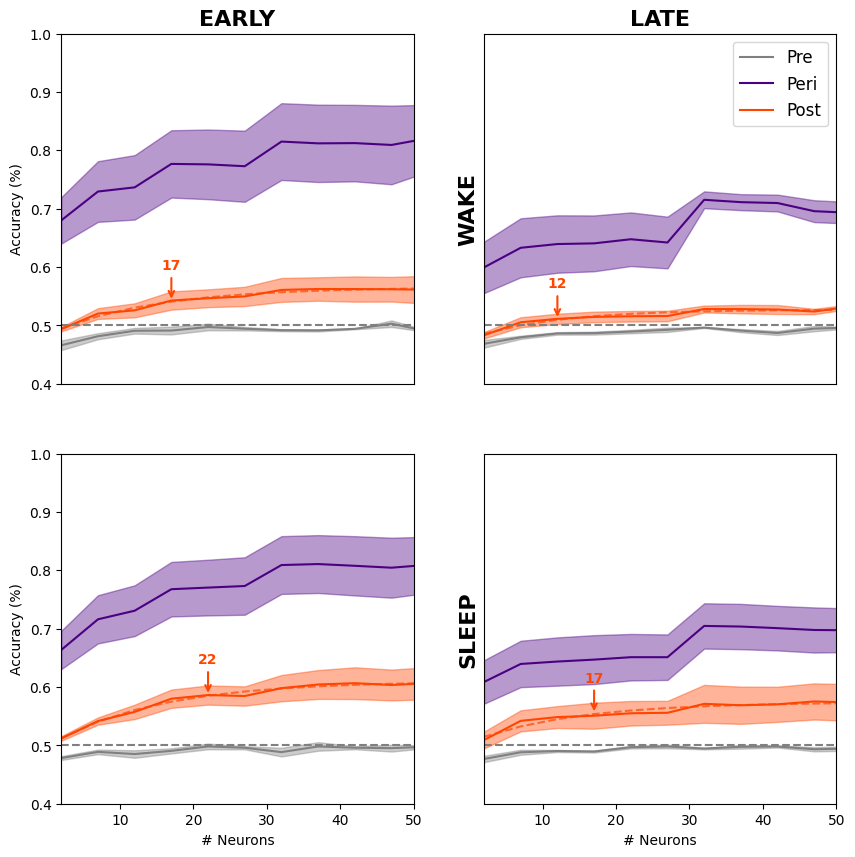

In [30]:
import numpy as np
from scipy.optimize import curve_fit

def exp_saturation(x, a, b, tau):
    return a - (a - b) * np.exp(-x / tau)

def plot_accuracy_vs_neurons(axs, df_summary, window_colors):
    states = ['wake', 'sleep']
    regions = ['low', 'high']
    
    for col_idx, region in enumerate(regions):
        for row_idx, state in enumerate(states):
            ax = axs[row_idx][col_idx]
            
            sub_df = df_summary[(df_summary['State'] == state) & (df_summary['Region'] == region)]

            for window, color in window_colors.items():
                df_win = sub_df[sub_df['TimeWindow'] == window]
                if df_win.empty:
                    continue

                x = df_win['N_Neurons'].values
                y = df_win['Accuracy_mean'].values

                # Plot raw curve
                ax.plot(x, y, label=window, color=color)
                ax.fill_between(x,
                                df_win['Accuracy_mean'] - df_win['Accuracy_sem'],
                                df_win['Accuracy_mean'] + df_win['Accuracy_sem'],
                                color=color, alpha=0.4)

                # --- Fit exponential saturation ---
                if window == 'Persistence':
                    try:
                        p0 = [y.max(), y.min(), 10]  # initial guess: plateau, intercept, tau
                        popt, _ = curve_fit(exp_saturation, x, y, p0=p0, maxfev=10000)
                        a, b, tau = popt
                        fit_y = exp_saturation(x, *popt)
                        ax.plot(x, fit_y, '--', color=color, alpha=0.7)
    
                        # Define plateau as neuron count where curve reaches 95% of asymptote
                        plateau_acc = a * 0.95
                        plateau_idx = np.where(fit_y >= plateau_acc)[0][0]
                        plateau_neurons = x[plateau_idx]
                        ax.annotate(
                            f"{plateau_neurons}",
                            xy=(plateau_neurons, fit_y[plateau_idx]),          # arrow tip (plateau point)
                            xytext=(plateau_neurons, fit_y[plateau_idx] + 0.05),  # text location offset
                            arrowprops=dict(arrowstyle="->", color=color, lw=1.5),
                            fontsize=10, color=color, fontweight="bold",
                            ha="center", va="bottom"
                        )
                        print(f'{state}-{region} {window}: plateau={a:.3f}, neurons≈{plateau_neurons}')
    
                    except Exception as e:
                        print(f'Fit failed for {state}-{region}-{window}: {e}')

            ax.axhline(0.5, linestyle='--', color='gray')
            ax.set_ylim(0.4, 1)
            ax.set_xlim(left=df_summary['N_Neurons'].min(), right=50)

            if row_idx == 1:
                ax.set_xlabel('# Neurons')
            else:
                ax.set_xticks([])
                ax.set_title(f'{name_mapping[region].upper()}', fontsize=16, weight='bold')

            if col_idx == 0:
                ax.set_ylabel('Accuracy (%)')
            else:
                ax.set_yticks([])
                ax.set_ylabel(f'{name_mapping[state].upper()}', fontsize=16, weight='bold')
            
            if (row_idx == 0) & (col_idx == 1):
                handles, labels = ax.get_legend_handles_labels()
                labels = [name_mapping[label] for label in labels]
                ax.legend(handles, labels, fontsize=12) 
                                
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

plot_accuracy_vs_neurons(axs, df_summary, window_colors)

## Plotting: Dimensionality vs. Number of Neurons

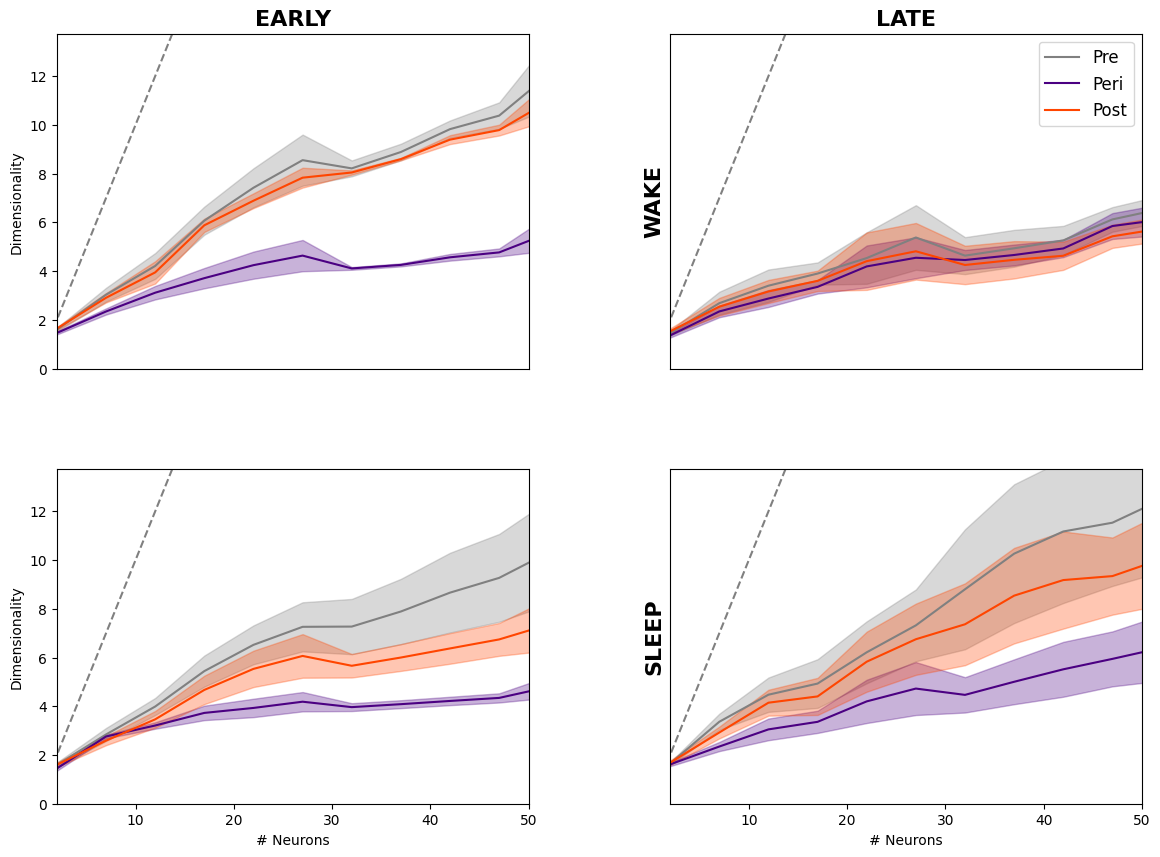

In [31]:
import matplotlib.pyplot as plt

def plot_dimensionality_vs_neurons(axs, df_summary, window_colors):
    states = ['wake', 'sleep']
    regions = ['low', 'high']

    for col_idx, region in enumerate(regions):
        for row_idx, state in enumerate(states):
            ax = axs[row_idx][col_idx]
            sub_df = df_summary[(df_summary['State'] == state) & (df_summary['Region'] == region)]

            for window, color in window_colors.items():
                df_win = sub_df[sub_df['TimeWindow'] == window]
                if df_win.empty:
                    continue
                ax.plot(df_win['N_Neurons'], df_win['Dimensionality_mean'], label=name_mapping[window], color=color)
                ax.fill_between(df_win['N_Neurons'],
                                df_win['Dimensionality_mean'] - df_win['Dimensionality_sem'],
                                df_win['Dimensionality_mean'] + df_win['Dimensionality_sem'],
                                color=color, alpha=0.3)
                
            ax.plot([0, max(df_summary['N_Neurons'])], [0, max(df_summary['N_Neurons'])], linestyle='--', color='gray')

            ax.set_xlim(left=df_summary['N_Neurons'].min(), right=50)
            ax.set_ylim(bottom=0, top=max(df_summary['Dimensionality_mean']))
            if row_idx == 1:
                ax.set_xlabel('# Neurons')
            else:
                ax.set_xticks([])
                ax.set_title(f'{name_mapping[region].upper()}', fontsize=16, weight='bold')

            if col_idx == 0:
                ax.set_ylabel('Dimensionality')
            else:
                ax.set_yticks([])
                ax.set_ylabel(f'{name_mapping[state].upper()}', fontsize=16, weight='bold')
            
            if (row_idx == 0) & (col_idx == 1):
                handles, labels = ax.get_legend_handles_labels()
                labels = [label for label in labels]
                ax.legend(handles, labels, fontsize=12)
    
            # Only collect legend handles/labels from one subplot
            handles, labels = axs[0][1].get_legend_handles_labels()
    return handles, labels

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.subplots_adjust(hspace=0.3, wspace=0.3)

handles, labels = plot_dimensionality_vs_neurons(axs, df_summary, window_colors)

## Final Figure Assembly (Figure 5)

wake-low Persistence: plateau=0.566, neurons≈17
sleep-low Persistence: plateau=0.610, neurons≈22
wake-high Persistence: plateau=0.527, neurons≈12
sleep-high Persistence: plateau=0.574, neurons≈17
Sound loaded successfully. Duration: 2.56 seconds
Sound loaded successfully. Duration: 2.56 seconds
1.6878758390959092e-09
2.473844368466871e-06
4.696458777431189e-10
2.3215617761529472e-07


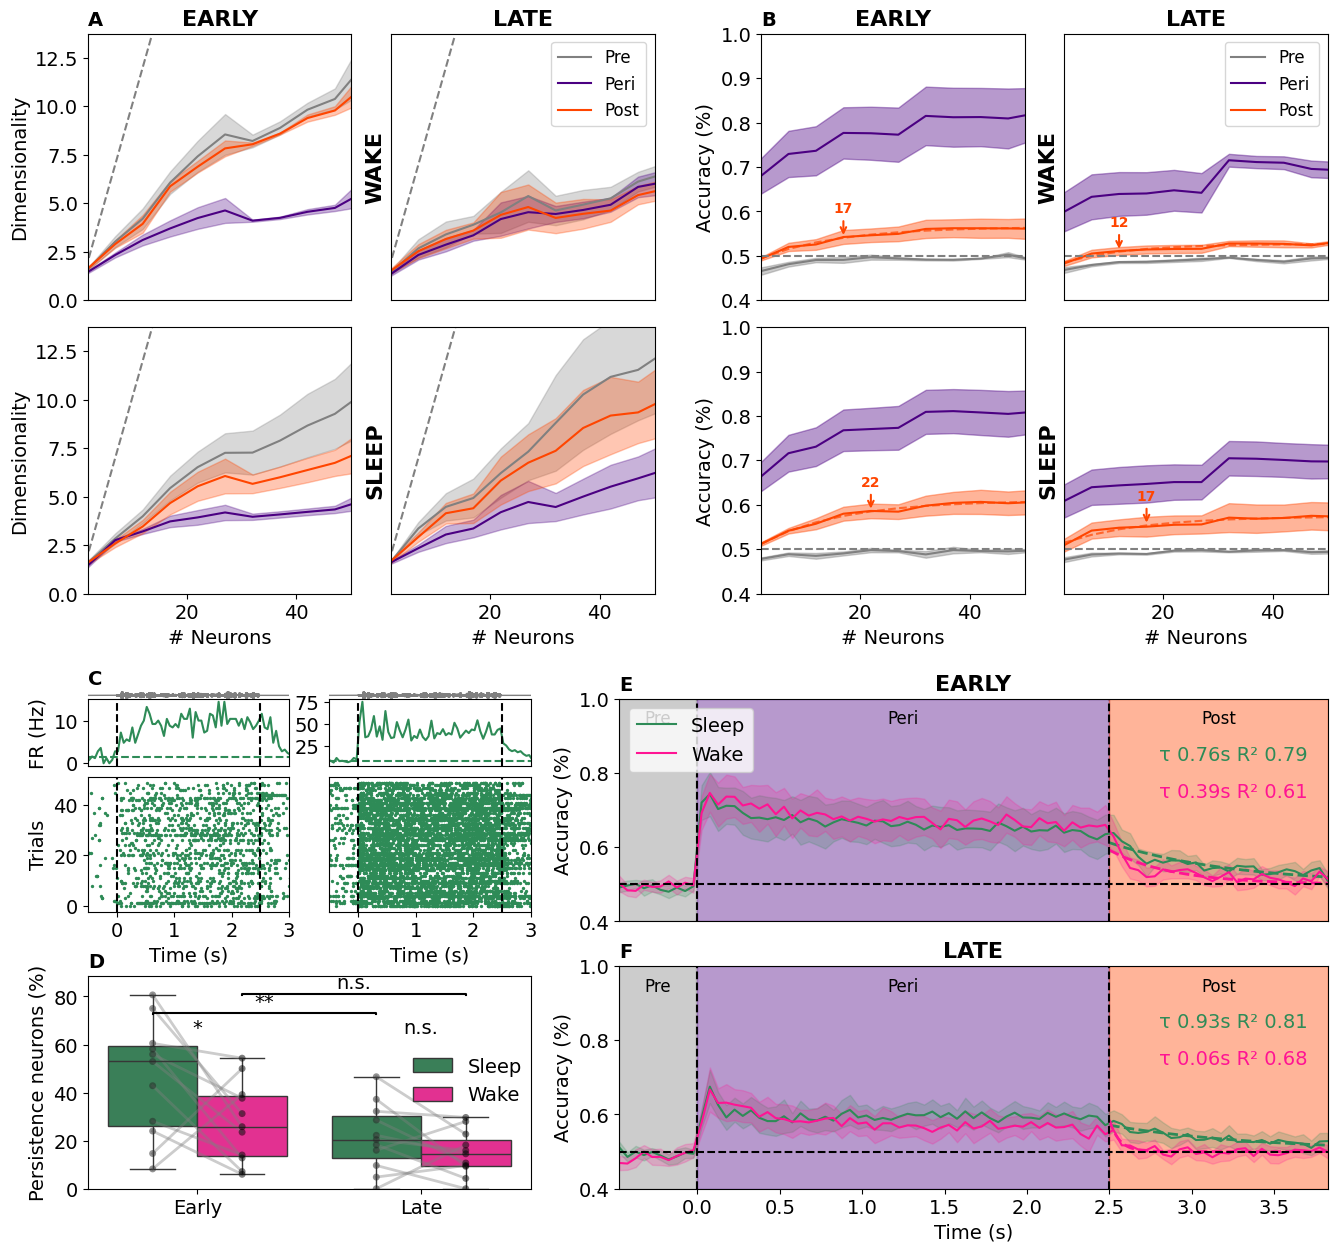

In [32]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl

plt.style.use('default')  # resets to pre-Seaborn/Matplotlib default

fig = plt.figure(figsize=(16, 15))
mpl.rcParams.update({
    'font.size': 14,              # base font size for everything
    'axes.labelsize': 14,         # x/y axis labels
    'axes.titlesize': 14,         # subplot titles (e.g., A–I)
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 14,
})

outer_gs = gridspec.GridSpec(2, 2, hspace=0.2, width_ratios=[1, 1], height_ratios=[8/8, 7/8])

# First row
gs_first = gridspec.GridSpecFromSubplotSpec(2, 5, subplot_spec=outer_gs[0, :], width_ratios=[1, 1, 0.08, 1, 1])
# Dimensionality vs number of neurons
gs_A = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs_first[0:2, 0:2], hspace=0.1, wspace=0.15)
axs_dims_num = np.array([[fig.add_subplot(gs_A[i, j]) for j in range(2)] for i in range(2)])
plot_dimensionality_vs_neurons(axs_dims_num, df_summary, window_colors)
axs_dims_num[0, 0].set_title('A', loc='left', fontweight='bold')

# Accuracy vs number of neurons
gs_B = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs_first[0:2, 3:5], hspace=0.1, wspace=0.15)
axs_acc_num = np.array([[fig.add_subplot(gs_B[i, j]) for j in range(2)] for i in range(2)])
plot_accuracy_vs_neurons(axs_acc_num, df_summary, window_colors)
axs_acc_num[0, 0].set_title('B', loc='left', fontweight='bold')

# Second row
gs_second = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=outer_gs[1, :], wspace=0.5)

# Romo examples
gs_A = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_second[0:2], hspace=0.3, wspace=0.3)
gs_romo_examples = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs_A[0], height_ratios=[1, 2], hspace=0.1)

ax_psth0 = fig.add_subplot(gs_romo_examples[0,0])
ax_raster0 = fig.add_subplot(gs_romo_examples[1,0])
plot_units_persist(results_units, ax_psth0, ax_raster0, 214, 400, plot_titles=True)
fig.align_ylabels([ax_psth0, ax_raster0])

ax_psth1 = fig.add_subplot(gs_romo_examples[0,1])
ax_raster1 = fig.add_subplot(gs_romo_examples[1,1])
plot_units_persist(results_units, ax_psth1, ax_raster1, 334, 400, plot_titles=False)
fig.align_ylabels([ax_psth1, ax_raster1])
ax_psth0.set_title('C', loc='left', fontweight='bold', pad=10)

# Romo percent
ax_pct = fig.add_subplot(gs_A[1])
plot_romo(ax_pct, df_romo, df_contrasts)
ax_pct.set_title('D', loc='left', fontweight='bold')

# Accuracy results
gs_EF = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_second[2:5])
axs_acc_model = np.array([fig.add_subplot(gs_EF[j]) for j in range(0,2)])
plot_avg_accuracy_by_state(axs_acc_model, mean_std_time_acc, t_hist)
axs_acc_model[0].set_title('E', loc='left', fontweight='bold')
axs_acc_model[1].set_title('F', loc='left', fontweight='bold')

fig.savefig(DATA_PATH + r"\Figure_5.pdf", format='pdf', dpi=300, transparent=True)
fig.savefig(DATA_PATH + r"\Figure_5.tiff", bbox_inches='tight', dpi=300, transparent=True)
fig.savefig(DATA_PATH + r"\Figure_5.jpg", bbox_inches='tight', dpi=300)